In [1]:
import json
import re
import matplotlib.pyplot as plt
from toolz.functoolz import thread_last

def plot_valist(va_pairs: list[tuple[float, float]], title: str, va_pairs2: list[tuple[float, float]] = []):
    vals, arous = zip(*va_pairs)
    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(vals, arous, c='C0', edgecolor='k')
    if va_pairs2:
        x, y = zip(*va_pairs2)
        ax.scatter(x, y, c="y")
    ax.set_xlabel("Valence")
    ax.set_ylabel("Arousal")
    ax.set_title(title)
    ax.grid(True)
    # helper integer alignment lines
    # vmin, vmax = math.floor(min(vals)), math.ceil(max(vals))
    # amin, amax = math.floor(min(arous)), math.ceil(max(arous))
    # for x in range(vmin, vmax+1):
    #     ax.axvline(x=x, color='gray', linewidth=0.6, alpha=0.6)
    # for y in range(amin, amax+1):
    #     plt.axhline(y=y, color='gray', linewidth=0.6, alpha=0.6)
    # plt.xlim(vmin - 0.5, vmax + 0.5)
    # plt.ylim(amin - 0.5, amax + 0.5)
    # if annotate:
    #     for i, (x, y) in enumerate(va_pairs):
    #         plt.text(x, y, str(i), fontsize=8, va='bottom', ha='right')
    # plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

def _va_filter(va_str: str):
    float_match = re.compile(r"([0-9.]+)#([0-9.]+)")
    m = re.search(float_match, va_str)
    if m:
        return m.group()
    else:
        print("warn: no va found!")
        return None

def asqp2valist(filename: str):
    vaList: list[tuple[float, float]] = []
    with open(filename) as f:
        asqp_json_list = f.readlines()
    for asqp_json in asqp_json_list:
        i = json.loads(asqp_json)
        for quad in i["Quadruplet"]:
            va_str = quad["VA"]
            assert(isinstance(va_str, str))
                # OMG there is a VA score contains string
                # and even there is NO score in
            x = _va_filter(va_str)
            if x:
                x = tuple(float(y) for y in x.split('#')[:2])
                vaList.append(x)
            else:
                print("warn: no VA score in va_str:")
                print(va_str)
                continue
    return vaList


def detect_duplicate(filename: str):
    with open(filename) as f:
        json_list = f.readlines()
    for json_s in json_list:
        i = json.loads(json_s)
        quad_keywords = {}
        for quad in i['Quadruplet']:
            AOC_str = str.join('_', map(quad.get, ('Aspect', 'Opinion', 'Category')))
            if AOC_str in quad_keywords and quad_keywords[AOC_str] != quad["VA"]:
                print("AOC_str duplicated & VA varies: ", AOC_str)
                print("ID: ", i["ID"])
            quad_keywords[AOC_str] = quad["VA"]
    return None

def _quads_rm_dup(quads: list[dict[str, str]]):
    quads_set = set(map(repr,quads))
    return list(map(eval,quads_set))

def _quads_clear_va(quads: list[dict[str, str]]):
    for q in quads:
        q['VA'] = _va_filter(q['VA']) or ''
    return quads
    
def map_jsonl_quads(jsonlist: list[str]):
    my_json_list: list[str] = []
    for json_s in jsonlist:
        i = json.loads(json_s)
        i['Quadruplet'] = thread_last(
            i['Quadruplet'],
            _quads_rm_dup,
            _quads_clear_va
        )
        my_json_list.append(json.dumps(i, ensure_ascii=False))
    return my_json_list


In [2]:
names = (
    'eng_laptop',
    'eng_restaurant',
    # 'jpn_hotel',
    'rus_restaurant',
    # 'tat_restaurant',
    'ukr_restaurant',
    'zho_restaurant',
    'zho_laptop',
)

In [3]:
from evaluation_script.metrics_subtask_1_2_3 import read_jsonl_file, evaluate_predictions
csvs = []
header = 'cF1,cTP,TP,FP,FN'
for i in ('task3_t1_p1_k10', 'task3_t7_p7_k20'):
    print(i)
    for name in names:
        print(name)
        gold_path = f"./task-dataset/track_a/subtask_3/{name.split('_')[0]}/{name}_dev_task3.jsonl"
        pred_path = f'./{i}/subtask_3/pred_{name}.jsonl'
        result = evaluate_predictions(
            read_jsonl_file(gold_path, 3, 'gold'),
            read_jsonl_file(pred_path),
            3
        )
        print(result)
        assert(result is not None)
        csvs.append([i, name]+[result[x] for x in header.split(',')])

print(header)
for i in csvs:
    for j in i:
        print(j,end=',')
    print()



task3_t1_p1_k10
eng_laptop

--- Evaluation Results ---
True Positives (TP): 111.0000
True Positives (cTP): 103.1461
False Positives (FP): 200
False Negatives (FN): 206
cPrecision: 0.3317
cRecall: 0.3254
cF1: 0.3285
{'cTP': 103.14608658449175, 'TP': 111, 'FP': 200, 'FN': 206, 'cPrecision': 0.3316594423938642, 'cRecall': 0.3253819766072295, 'cF1': 0.32849072160666165}
eng_restaurant

--- Evaluation Results ---
True Positives (TP): 328.0000
True Positives (cTP): 307.0793
False Positives (FP): 88
False Negatives (FN): 80
cPrecision: 0.7382
cRecall: 0.7526
cF1: 0.7453
{'cTP': 307.07931954087826, 'TP': 328, 'FP': 88, 'FN': 80, 'cPrecision': 0.7381714412040343, 'cRecall': 0.7526453910315644, 'cF1': 0.7453381542254327}
rus_restaurant

--- Evaluation Results ---
True Positives (TP): 62.0000
True Positives (cTP): 55.9061
False Positives (FP): 53
False Negatives (FN): 40
cPrecision: 0.4861
cRecall: 0.5481
cF1: 0.5153
{'cTP': 55.90609434276121, 'TP': 62, 'FP': 53, 'FN': 40, 'cPrecision': 0.4861399

In [14]:
for i in ('task3_t1_p1_k10', 'task3_t7_p7_k20'):
    print(i)
    for name in names:
        myfile = f"./{i}/subtask_3/pred_{name}.jsonl"
        print(name)
        jl: list[str]
        with open(myfile) as f:
            jl = f.readlines()
        jl = map_jsonl_quads(
            jl
        )
        with open(myfile, "w") as f:
            f.writelines(x+'\n' for x in jl)

task3_t1_p1_k10
eng_laptop
eng_restaurant
rus_restaurant
ukr_restaurant
zho_restaurant
zho_laptop
task3_t7_p7_k20
eng_laptop
eng_restaurant
rus_restaurant
ukr_restaurant
zho_restaurant
zho_laptop


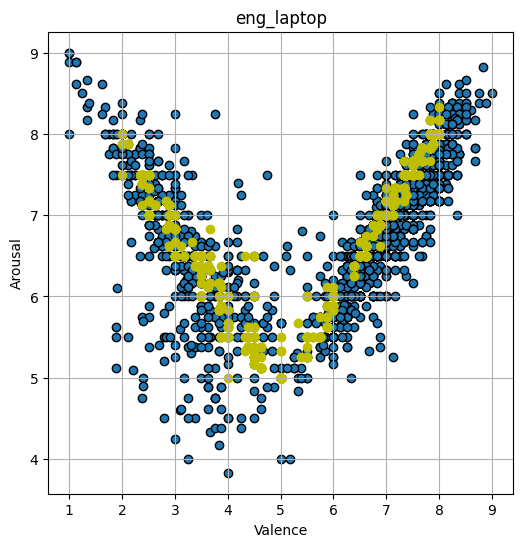

warn: no VA score in va_str:
special sauce 


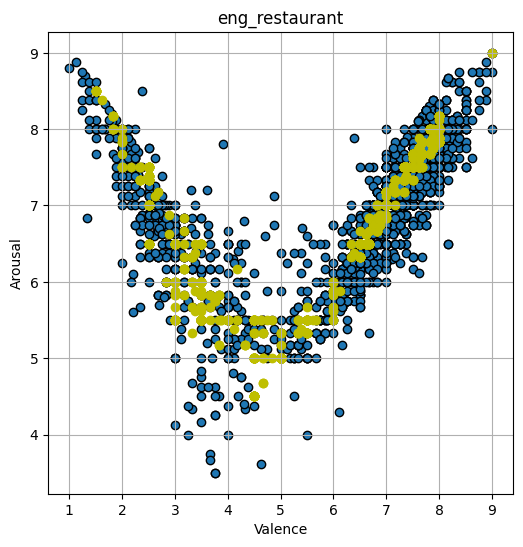

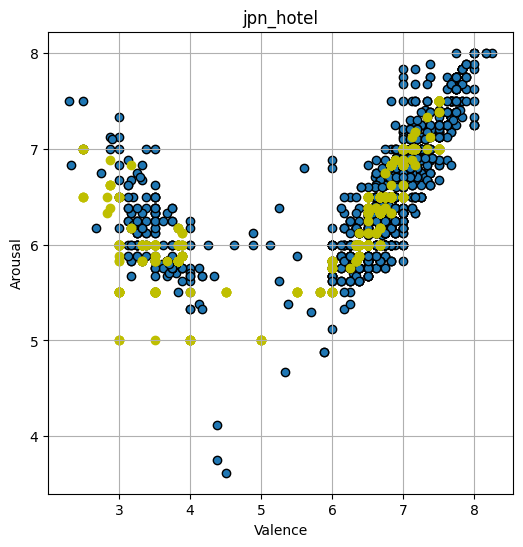

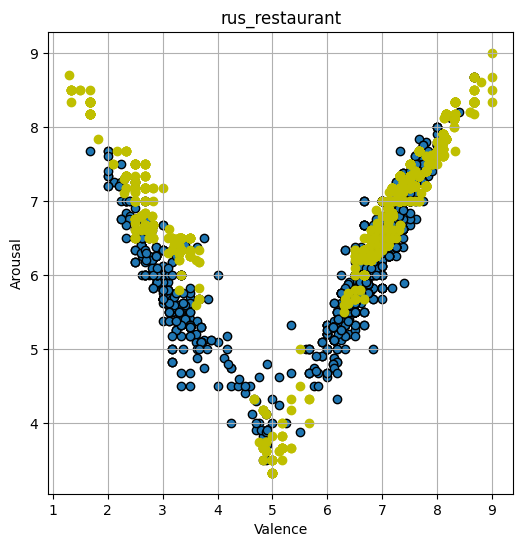

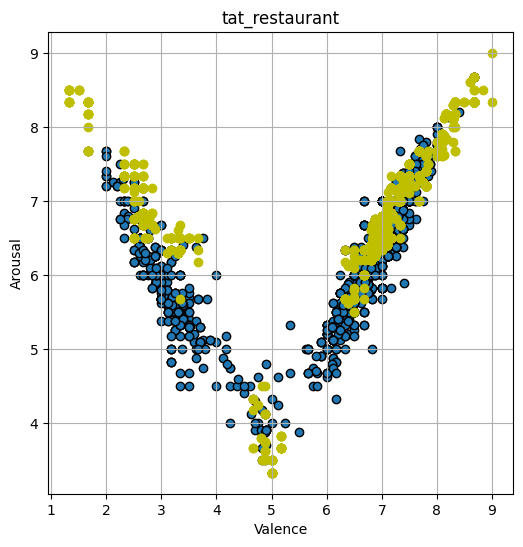

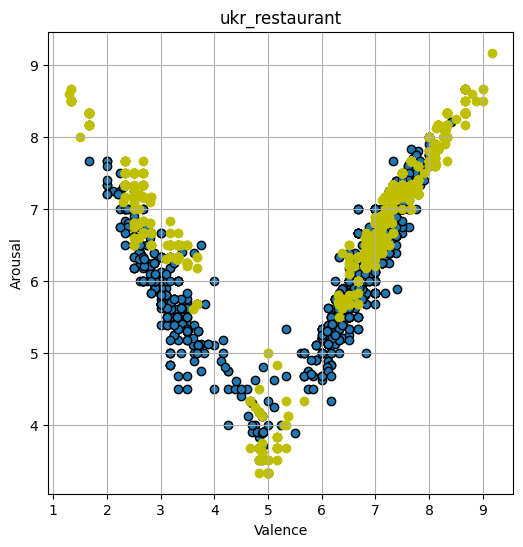

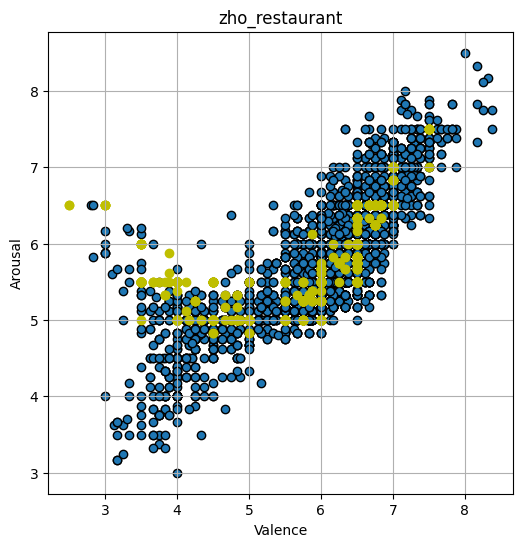

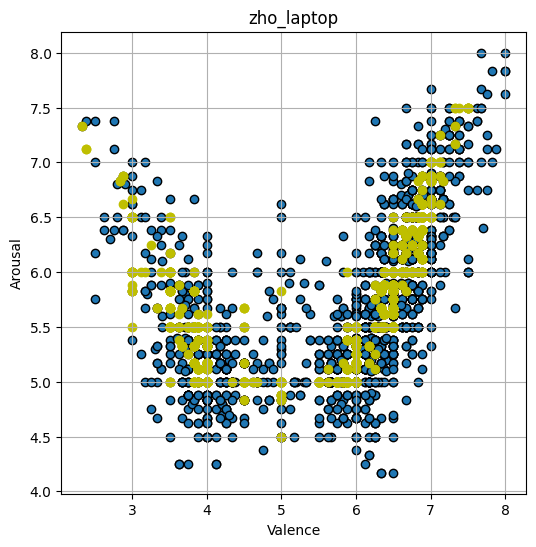

In [ ]:

for name in names:
    ours = asqp2valist(f"./subtask_3/pred_{name}.jsonl")
    lang = name.split("_", 1)[0]
    gold = asqp2valist(f"./task-dataset/track_a/subtask_3/{lang}/{name}_test_task3.jsonl")
    plot_valist(gold, name, ours)